# ___Data wrangling for the paper draft; with `FRED 4.0`___
--------------------------------------

In [1]:
!python --version

Python 3.14.5


The system cannot find the path specified.


In [37]:
import numpy as np
from numpy.typing import NDArray
import pandas as pd
import matplotlib.pyplot as plt
from numba import njit, vectorize, float32, float64
from scipy.stats import pearsonr

In [5]:
# including all the traits Luke advised

COLLABORATION_GRADIENT_TRAITS = [
    "F00679", # RD
    "F00727", # SRL
    # "F00104", # RCT
]

CONSERVATION_GRADIENT_TRAITS = [
    "F00709", # RTD
    # "F00261", # RN
]

CHOSEN_ROOT_TRAITS = COLLABORATION_GRADIENT_TRAITS + CONSERVATION_GRADIENT_TRAITS

CHOSEN_TRAITS_DICT = {
    "F00709":  "RTD",
    # "F00261":  "RN",
    "F00679":  "RD",
    "F00727":  "SRL",
    # "F00104":  "RCT",
}

PLANT_TAXONOMY_ACCEPTED_COLUMNS = [
    "F01286", # Genus of plant according to The Plant List
    "F01287", # Species epithet of plant according to The Plant List
    "F01289", # Family of plant according to The Plant List
    "F01290"  # Order of plant.
]

BINOMINAL_NAME = ["F01286", "F01287"]

BINOMINAL_NAME_DATA_SOURCE = ["F00018", "F00019"]

MISC = [
    "F00056", # root order
    "F00645", # Mycorrhiza_Type_Data source
   # "F01282" # Mycorrhiza_Type_Maherali - not present in FRED 4
]

TAXONOMY_COLUMNS_TO_CROSSCHECK = [
    "F01289", "F01290", # from FRED 4.0
    "family", "order", "group" # from the lookup table
]

# families Luke advised as important
FAMILIES_NOT_TO_MISS = ("Zamiaceae", "Cycadaceae", "Magnoliaceae", "Lauraceae", # generally thick rooted absorptive roots
                       "Cyperaceae", "Brassicaceae") # NM families

In [6]:
fred = pd.read_csv(r"../../data/chapter2/FRED/FRED4_Entire_Database_2026.csv", low_memory=False, header=0, skiprows=range(1, 7), encoding="latin1") # FRED 4.0
meta = pd.read_csv(r"../../data/chapter2/FRED/FRED3_Column_Definitions_2021.csv", usecols=["column_id", "name", "units"], index_col="column_id")

lookup = pd.read_csv(r"../../data/chapter2/plant_lookup.csv", low_memory=False, encoding="latin1", usecols=["genus", "apweb.family", # let's stick the the family info from APG website
                                                                                                         "order", "group"], index_col="genus").rename(mapper={"apweb.family": "family"}, axis=1) 

# thought we could use the data source's binominal names where FRED's binominal names are missing but looks like that won't help :/
# drop all the rows that do not have genus and species names
fred.dropna(subset=BINOMINAL_NAME, inplace=True)

# strip off all the unnecessary spaces
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS] = fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].apply(lambda col: col.str.strip())

In [7]:
meta.loc[BINOMINAL_NAME + BINOMINAL_NAME_DATA_SOURCE + CHOSEN_ROOT_TRAITS + MISC, :]

,name,units
column_id,,
F01286,Plant taxonomy_Accepted genus_TPL,NaN
F01287,Plant Taxonomy_Accepted species_TPL,NaN
F00018,Plant taxonomy_Genus_Data Source,NaN
F00019,Plant taxonomy_Species_Data source,NaN
F00679,Root diameter,mm
F00727,Specific root length (SRL),m/g
F00709,Root tissue density (RTD),g/cm3
F00056,Root order,NaN
F00645,Mycorrhiza_Type_Data source,NaN


In [104]:
# records with missing binominal names aren't useful to us 
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].isna().mean() # dropna(subset=BINOMINAL_NAME)

F01286    0.000000
F01287    0.000000
F01289    0.000000
F01290    0.000000
F00679    0.796387
F00727    0.796594
F00709    0.844053
dtype: float64

In [105]:
# that many records with missing binominal names???
fred.loc[:, BINOMINAL_NAME + BINOMINAL_NAME_DATA_SOURCE].isna().sum()

F01286     0
F01287     0
F00018     0
F00019    60
dtype: int64

### ___$1^{st}$ order roots___
__________________

In [109]:
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS + MISC].query(r"F00056==1")

,F01286,F01287,F01289,F01290,F00679,F00727,F00709,F00056,F00645
0,Dicranopteris,linearis,Gleicheniaceae,Gleicheniales,NaN,NaN,NaN,1.0,AM
3,Cunninghamia,lanceolata,Cupressaceae,Cupressales,NaN,NaN,NaN,1.0,AM
6,Magnolia,baillonii,Magnoliaceae,Magnoliales,NaN,NaN,NaN,1.0,AM
11,Acacia,auriculiformis,Fabaceae,Fabales,NaN,NaN,NaN,1.0,AM
15,Polyspora,axillaris,Theaceae,Ericales,NaN,NaN,NaN,1.0,AM
...,...,...,...,...,...,...,...,...,...
70350,Pinus,strobus,Pinaceae,Pinales,0.421385,17.805402,0.337226,1.0,EM
70354,Tsuga,canadensis,Pinaceae,Pinales,0.373780,30.873103,0.204034,1.0,EM
70358,Sciadopitys,verticillata,Sciadopityaceae,Cupressales,0.620386,29.212460,0.125136,1.0,AM
70363,Cephalotaxus,harringtonii,Cephalotaxaceae,Cupressales,0.626291,21.950489,0.125251,1.0,AM


In [110]:
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS + MISC].query(r"F00056==1").loc[:, BINOMINAL_NAME].drop_duplicates()

,F01286,F01287
0,Dicranopteris,linearis
3,Cunninghamia,lanceolata
6,Magnolia,baillonii
11,Acacia,auriculiformis
15,Polyspora,axillaris
...,...,...
70295,Encephalartos,gratus
70299,Zamia,lucayana
70303,Chamaecyparis,pisifera
70328,Ephedra,distachya


In [111]:
fred.loc[:, CHOSEN_ROOT_TRAITS + MISC].query(r"F00056==1").isna().mean().rename(index=CHOSEN_TRAITS_DICT)

RD        0.266157
SRL       0.668451
RTD       0.726195
F00056    0.000000
F00645    0.738815
dtype: float64

### ___RD $\le$ 2.0 mm___
-----------------------

In [112]:
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"F00679 <= 2.000").dropna(subset=CHOSEN_ROOT_TRAITS)

,F01286,F01287,F01289,F01290,F00679,F00727,F00709
236,Larix,gmelinii,Pinaceae,Pinales,0.319412,32.211568,0.354286
237,Larix,gmelinii,Pinaceae,Pinales,0.411555,25.480815,0.294286
238,Larix,gmelinii,Pinaceae,Pinales,0.527621,12.980828,0.382857
239,Larix,gmelinii,Pinaceae,Pinales,0.846975,6.250067,0.334286
241,Larix,gmelinii,Pinaceae,Pinales,0.307450,34.615414,0.382857
...,...,...,...,...,...,...,...
71902,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.740062,8.685170,0.224091
71903,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.739066,8.855820,0.228155
71904,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.666566,9.584048,0.228379
71905,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.639820,10.362667,0.265331


In [113]:
# focusing on rows that have data for all the three traits
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"F00679 <= 2.000").dropna(subset=CHOSEN_ROOT_TRAITS).loc[:, BINOMINAL_NAME].drop_duplicates()

,F01286,F01287
236,Larix,gmelinii
266,Fraxinus,mandshurica
382,Populus,trichocarpa
386,Populus,tremula
827,Cinnamomum,micranthum
...,...,...
71813,Sorocea,muriculata
71814,Stachyarrhena,acuminata
71815,Trymatococcus,amazonicus
71816,Zygia,inaequalis


In [114]:
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"F00679 <= 2.000").dropna(subset=CHOSEN_ROOT_TRAITS).isna().mean().rename(index=CHOSEN_TRAITS_DICT)

F01286    0.0
F01287    0.0
F01289    0.0
F01290    0.0
RD        0.0
SRL       0.0
RTD       0.0
dtype: float64

In [116]:
# inspect the coverage of thick rooted families in this subset
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"(F00679 <= 2.000) and F01289.isin(@FAMILIES_NOT_TO_MISS)").dropna(subset=CHOSEN_ROOT_TRAITS).drop_duplicates(subset=PLANT_TAXONOMY_ACCEPTED_COLUMNS)

,F01286,F01287,F01289,F01290,F00679,F00727,F00709
827,Cinnamomum,micranthum,Lauraceae,Laurales,0.502558,24.150012,0.209434
832,Magnolia,odora,Magnoliaceae,Magnoliales,0.500991,24.405710,0.206190
837,Cinnamomum,chekiangense,Lauraceae,Laurales,0.499444,23.180490,0.214529
1450,Cryptocarya,chinensis,Lauraceae,Laurales,1.177410,9.677503,0.248276
1572,Gahnia,procera,Cyperaceae,Poales,0.320000,58.700000,0.190000
...,...,...,...,...,...,...,...
71756,Ocotea,scabrella,Lauraceae,Laurales,0.726000,9.060000,0.275000
71757,Ocotea,splendens,Lauraceae,Laurales,0.589000,11.920000,0.321000
71804,Rhodostemonodaphne,crenaticupula,Lauraceae,Laurales,0.703000,7.990000,0.382000
71805,Rhodostemonodaphne,paniculata,Lauraceae,Laurales,0.714000,4.670000,0.479000


In [117]:
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"(F00679 <= 2.000) and F01289.isin(@FAMILIES_NOT_TO_MISS)").dropna(subset=CHOSEN_ROOT_TRAITS).drop_duplicates(subset=PLANT_TAXONOMY_ACCEPTED_COLUMNS).\
        groupby("F01289").agg({"F01289": "count"})

,F01289
F01289,
Brassicaceae,18
Cycadaceae,2
Cyperaceae,17
Lauraceae,111
Magnoliaceae,29
Zamiaceae,3


In [118]:
cutoff_2mm_taxa = fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"(F00679 <= 2.000)").dropna(subset=CHOSEN_ROOT_TRAITS).loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].\
    drop_duplicates(subset=BINOMINAL_NAME).sort_values(["F01289", "F01290", "F01286", "F01287"]).reset_index(drop=True)
cutoff_2mm_taxa

,F01286,F01287,F01289,F01290
0,Strobilanthes,dimorphotricha,Acanthaceae,Lamiales
1,Actinidia,kolomikta,Actinidiaceae,Ericales
2,Saurauia,herthae,Actinidiaceae,Ericales
3,Liquidambar,formosana,Altingiaceae,Saxifragales
4,Liquidambar,gracilipes,Altingiaceae,Saxifragales
...,...,...,...,...
1435,Dioon,rzedowskii,Zamiaceae,Cycadales
1436,Encephalartos,gratus,Zamiaceae,Cycadales
1437,Zamia,lucayana,Zamiaceae,Cycadales
1438,Alpinia,japonica,Zingiberaceae,Zingiberales


In [119]:
# WE HAVE SPECIES CLASSIFIED UNDER DIFFERENT HIGHER TAXA IN THIS SUBSET!!!!!

### ___RD $\le$ 1.00 mm___
------------------

In [120]:
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"F00679 <= 1.000").dropna(subset=CHOSEN_ROOT_TRAITS)

,F01286,F01287,F01289,F01290,F00679,F00727,F00709
236,Larix,gmelinii,Pinaceae,Pinales,0.319412,32.211568,0.354286
237,Larix,gmelinii,Pinaceae,Pinales,0.411555,25.480815,0.294286
238,Larix,gmelinii,Pinaceae,Pinales,0.527621,12.980828,0.382857
239,Larix,gmelinii,Pinaceae,Pinales,0.846975,6.250067,0.334286
241,Larix,gmelinii,Pinaceae,Pinales,0.307450,34.615414,0.382857
...,...,...,...,...,...,...,...
71902,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.740062,8.685170,0.224091
71903,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.739066,8.855820,0.228155
71904,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.666566,9.584048,0.228379
71905,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.639820,10.362667,0.265331


In [121]:
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"F00679 <= 1.000").dropna(subset=CHOSEN_ROOT_TRAITS).loc[:, BINOMINAL_NAME].drop_duplicates()

,F01286,F01287
236,Larix,gmelinii
266,Fraxinus,mandshurica
382,Populus,trichocarpa
386,Populus,tremula
827,Cinnamomum,micranthum
...,...,...
71813,Sorocea,muriculata
71814,Stachyarrhena,acuminata
71815,Trymatococcus,amazonicus
71816,Zygia,inaequalis


In [122]:
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"F00679 <= 1.000").dropna(subset=CHOSEN_ROOT_TRAITS).isna().mean().rename(index=CHOSEN_TRAITS_DICT)

F01286    0.0
F01287    0.0
F01289    0.0
F01290    0.0
RD        0.0
SRL       0.0
RTD       0.0
dtype: float64

In [123]:
# inspect the thick rooted family coverage
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"(F00679 <= 1.000) and F01289.isin(@FAMILIES_NOT_TO_MISS)").dropna(subset=CHOSEN_ROOT_TRAITS).drop_duplicates(subset=PLANT_TAXONOMY_ACCEPTED_COLUMNS)

,F01286,F01287,F01289,F01290,F00679,F00727,F00709
827,Cinnamomum,micranthum,Lauraceae,Laurales,0.502558,24.150012,0.209434
832,Magnolia,odora,Magnoliaceae,Magnoliales,0.500991,24.405710,0.206190
837,Cinnamomum,chekiangense,Lauraceae,Laurales,0.499444,23.180490,0.214529
1572,Gahnia,procera,Cyperaceae,Poales,0.320000,58.700000,0.190000
1573,Gahnia,xanthocarpa,Cyperaceae,Poales,0.460000,45.600000,0.100000
...,...,...,...,...,...,...,...
71756,Ocotea,scabrella,Lauraceae,Laurales,0.726000,9.060000,0.275000
71757,Ocotea,splendens,Lauraceae,Laurales,0.589000,11.920000,0.321000
71804,Rhodostemonodaphne,crenaticupula,Lauraceae,Laurales,0.703000,7.990000,0.382000
71805,Rhodostemonodaphne,paniculata,Lauraceae,Laurales,0.714000,4.670000,0.479000


In [124]:
fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"(F00679 <= 1.000) and F01289.isin(@FAMILIES_NOT_TO_MISS)").dropna(subset=CHOSEN_ROOT_TRAITS).drop_duplicates(subset=PLANT_TAXONOMY_ACCEPTED_COLUMNS).\
    groupby("F01289").agg({"F01289": "count"})

,F01289
F01289,
Brassicaceae,5
Cycadaceae,2
Cyperaceae,12
Lauraceae,96
Magnoliaceae,28
Zamiaceae,3


In [125]:
# diff in species counts, all three traits

fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"(F00679 <= 2.000) and F01289.isin(@FAMILIES_NOT_TO_MISS)").dropna(subset=CHOSEN_ROOT_TRAITS).drop_duplicates(subset=PLANT_TAXONOMY_ACCEPTED_COLUMNS).\
    groupby("F01289").agg({"F01289": "count"}) - fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"(F00679 <= 1.000) and F01289.isin(@FAMILIES_NOT_TO_MISS)").dropna(subset=CHOSEN_ROOT_TRAITS).drop_duplicates(subset=PLANT_TAXONOMY_ACCEPTED_COLUMNS).\
    groupby("F01289").agg({"F01289": "count"})

,F01289
F01289,
Brassicaceae,13
Cycadaceae,0
Cyperaceae,5
Lauraceae,15
Magnoliaceae,1
Zamiaceae,0


In [126]:
# diff in species counts, RD & SRL

fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"(F00679 <= 2.000) and F01289.isin(@FAMILIES_NOT_TO_MISS)").dropna(subset=COLLABORATION_GRADIENT_TRAITS).drop_duplicates(subset=PLANT_TAXONOMY_ACCEPTED_COLUMNS).\
    groupby("F01289").agg({"F01289": "count"}) - fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"(F00679 <= 1.000) and F01289.isin(@FAMILIES_NOT_TO_MISS)").dropna(subset=COLLABORATION_GRADIENT_TRAITS).drop_duplicates(subset=PLANT_TAXONOMY_ACCEPTED_COLUMNS).\
    groupby("F01289").agg({"F01289": "count"})

,F01289
F01289,
Brassicaceae,14
Cycadaceae,0
Cyperaceae,5
Lauraceae,15
Magnoliaceae,1
Zamiaceae,0


In [127]:
# dropping NaNs only in RD and SRL

cutoff_1mm_taxa = fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS].query(r"(F00679 <= 1.000)").dropna(subset=COLLABORATION_GRADIENT_TRAITS).loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].\
    drop_duplicates(subset=BINOMINAL_NAME).sort_values(["F01289", "F01290", "F01286", "F01287"]).reset_index(drop=True)
cutoff_1mm_taxa

,F01286,F01287,F01289,F01290
0,Rungia,pectinata,Acanthaceae,Lamiales
1,Strobilanthes,dimorphotricha,Acanthaceae,Lamiales
2,Actinidia,kolomikta,Actinidiaceae,Ericales
3,Saurauia,herthae,Actinidiaceae,Ericales
4,Liquidambar,formosana,Altingiaceae,Saxifragales
...,...,...,...,...
1439,Dioon,rzedowskii,Zamiaceae,Cycadales
1440,Encephalartos,gratus,Zamiaceae,Cycadales
1441,Zamia,lucayana,Zamiaceae,Cycadales
1442,Alpinia,japonica,Zingiberaceae,Zingiberales


In [33]:
# SUSPECT THIS SUBSET ALSO HAS SPECIES CLASSIFIED UNDER MULTIPLE HIGHER RANKS!!!!!!!!

In [128]:
# see what species we are losing going from 2mm to 1mm cutoff

species_lost_2mm_to_1mm = np.setdiff1d(cutoff_2mm_taxa.loc[:, BINOMINAL_NAME].apply(' '.join, axis=1).unique(), 
                                        cutoff_1mm_taxa.loc[:, BINOMINAL_NAME].apply(' '.join, axis=1).unique())# .size
species_lost_2mm_to_1mm

array(['Aglaia squamulosa', 'Agrostis stolonifera', 'Alchemilla arvensis',
       'Alchemilla xanthochlora', 'Alopecurus geniculatus',
       'Aniba citrifolia', 'Aniba williamsii', 'Arabidopsis arenosa',
       'Arabidopsis thaliana', 'Arabis sagittata', 'Barbarea vulgaris',
       'Beilschmiedia brachythyrsa', 'Beilschmiedia percoriacea',
       'Beilschmiedia robusta', 'Bellis perennis', 'Berula erecta',
       'Brassica rapa', 'Briza media', 'Bromus sterilis',
       'Calamagrostis canescens', 'Campanula glomerata',
       'Campanula patula', 'Campanula persicifolia',
       'Campanula rapunculoides', 'Capsella bursa-pastoris',
       'Cardamine pratensis', 'Carex leporina', 'Carex muricata',
       'Carex ornithopoda', 'Carex praecox', 'Carex vulpina',
       'Centaurium erythraea', 'Cerastium glomeratum',
       'Cerastium pumilum', 'Cerastium semidecandrum',
       'Clinopodium acinos', 'Clusia latipes', 'Cruciata laevipes',
       'Cryptocarya densiflora', 'Cynanchica pyrenaica

In [35]:
species_lost_2mm_to_1mm = pd.DataFrame({"F01286": [_.split()[0] for _ in species_lost_2mm_to_1mm], "F01287": [_.split()[1] for _ in species_lost_2mm_to_1mm]})
species_lost_2mm_to_1mm

,F01286,F01287
0,Aglaia,squamulosa
1,Agrostis,stolonifera
2,Alchemilla,arvensis
3,Alchemilla,xanthochlora
4,Alopecurus,geniculatus
...,...,...
134,Veronica,officinalis
135,Veronica,serpyllifolia
136,Veronica,spicata
137,Viola,arvensis


In [36]:
# full taxonomic profile of the 139 species
species_lost_2mm_to_1mm = pd.merge(left=species_lost_2mm_to_1mm, left_on=BINOMINAL_NAME, right=cutoff_2mm_taxa, right_on=BINOMINAL_NAME, how="left").sort_values(["F01289", "F01290"] + BINOMINAL_NAME).reset_index(drop=True)
species_lost_2mm_to_1mm

,F01286,F01287,F01289,F01290
0,Berula,erecta,Apiaceae,Apiales
1,Ruscus,aculeatus,Asparagaceae,Asparagales
2,Bellis,perennis,Asteraceae,Asterales
3,Erigeron,acris,Asteraceae,Asterales
4,Hypochaeris,radicata,Asteraceae,Asterales
...,...,...,...,...
134,Galium,pumilum,Rubiaceae,Gentianales
135,Galium,verum,Rubiaceae,Gentianales
136,Sherardia,arvensis,Rubiaceae,Gentianales
137,Saxifraga,tridactylites,Saxifragaceae,Saxifragales


In [96]:
species_lost_2mm_to_1mm.to_csv(r"../../data/chapter2/FRED/subsets/species_lost_2mm_to_1mm_FRED4.csv", index=False)

In [39]:
# that's a lot of useful species
species_lost_2mm_to_1mm.query(r"F01289.isin(@FAMILIES_NOT_TO_MISS)").drop_duplicates()

,F01286,F01287,F01289,F01290
10,Arabidopsis,arenosa,Brassicaceae,Brassicales
11,Arabidopsis,thaliana,Brassicaceae,Brassicales
12,Arabis,sagittata,Brassicaceae,Brassicales
13,Barbarea,vulgaris,Brassicaceae,Brassicales
14,Brassica,rapa,Brassicaceae,Brassicales
15,Capsella,bursa-pastoris,Brassicaceae,Brassicales
16,Cardamine,pratensis,Brassicaceae,Brassicales
17,Erophila,verna,Brassicaceae,Brassicales
18,Lepidium,campestre,Brassicaceae,Brassicales
19,Sinapis,arvensis,Brassicaceae,Brassicales


In [129]:
# decide which columns in FRED 4.0 have mycorrhizal state info????
[col for col in fred.columns if ((fred.loc[:, col].dtype == pd.StringDtype(storage="python", na_value=np.nan)) and fred.loc[:, col].str.contains("AM").any())]

['F00004', 'F00006', 'F00043', 'F00645', 'F01160', 'F00079']

In [130]:
fred.loc[:, ('F00004', 'F00006', 'F00043', 'F00645', 'F01160', 'F00079')]

,F00004,F00006,F00043,F00645,F01160,F00079
0,"Long Y, Kong D, Chen Z, Zeng H. 2013. Variatio...",NaN,C3,AM,NaN,NaN
1,"Long Y, Kong D, Chen Z, Zeng H. 2013. Variatio...",NaN,C3,AM,NaN,NaN
2,"Long Y, Kong D, Chen Z, Zeng H. 2013. Variatio...",NaN,C3,AM,NaN,NaN
3,"Long Y, Kong D, Chen Z, Zeng H. 2013. Variatio...",NaN,C3,AM,NaN,NaN
4,"Long Y, Kong D, Chen Z, Zeng H. 2013. Variatio...",NaN,C3,AM,NaN,NaN
...,...,...,...,...,...,...
77554,"Kutschera L, Lichtenegger E, Sobotik M, Haas D...","Tumber-Davila SJ, Schenk HJ, Du E, and Jackson...",NaN,NaN,NaN,NaN
77555,"Kutschera L, Lichtenegger E (1960) Wurzelatlas...","Tumber-Davila SJ, Schenk HJ, Du E, and Jackson...",C3,NaN,NaN,NaN
77556,"Kutschera L, Lichtenegger E, Sobotik M, Haas D...","Tumber-Davila SJ, Schenk HJ, Du E, and Jackson...",NaN,NaN,NaN,NaN
77557,"Kutschera L, Lichtenegger E (1960) Wurzelatlas...","Tumber-Davila SJ, Schenk HJ, Du E, and Jackson...",C3,NaN,NaN,NaN


In [39]:
fred.loc[:, ('F00645', 'F01160', 'F00079')].dropna() # damn, FRED 3 has a row F01282 named Mycorrhiza_Type_Maherali, but FRED 4 hasn't

,F00645,F01160,F00079
1651,AM,control,RLD converted from 1m depth to 0.3m depth. Dat...
1656,AM,control,RLD converted from 1m depth to 0.3m depth. Dat...
1661,AM,control,RLD converted from 1m depth to 0.3m depth. Dat...
3581,EM,ambient CO2,"Diameter, diameter production, and diameter mo..."
3582,EM,ambient CO2,"Diameter, diameter production, and diameter mo..."
...,...,...,...
54022,AM,N10,AM colonization taken from graph using Grab It...
55131,AM,control,Plant species categorical data not found in TR...
55134,AM,control,Plant species categorical data not found in TR...
55140,AM,control,Plant species categorical data not found in TR...


### ___Choosing to proceed with an RD cutoff $\le$ 1.00 mm___
---------------------------------------------------------------------------------------

In [96]:
# final subset for the phylogenetics work; using traits - RD, SRL and RTD and using RD <= 1.00 mm as the cutoff criteria

subset = fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS + MISC].query(r"F00679 <= 1.000").reset_index(drop=True)
subset

,F01286,F01287,F01289,F01290,F00679,F00727,F00709,F00056,F00645
0,Populus,tremuloides,Salicaceae,Malpighiales,0.220000,NaN,NaN,NaN,NaN
1,Acer,negundo,Sapindaceae,Sapindales,0.280000,NaN,NaN,NaN,NaN
2,Juglans,nigra,Juglandaceae,Fagales,0.300000,NaN,NaN,NaN,NaN
3,Quercus,rubra,Fagaceae,Fagales,0.230000,NaN,NaN,NaN,NaN
4,Carya,glabra,Juglandaceae,Fagales,0.220000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
9679,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.740062,8.685170,0.224091,NaN,AM
9680,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.739066,8.855820,0.228155,NaN,AM
9681,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.666566,9.584048,0.228379,NaN,AM
9682,Handroanthus,ochraceus,Bignoniaceae,Lamiales,0.639820,10.362667,0.265331,NaN,AM


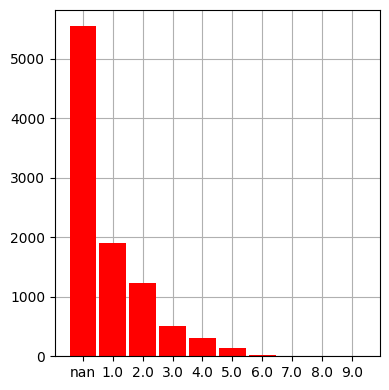

In [97]:
# examine the root orders within this RD <= 1.00 mm subset

freq = subset.F00056.value_counts(dropna=False)
fig, axes = plt.subplots()
fig.set_size_inches(4, 4)
axes.bar(x=freq.index.fillna(0), # without replacing with 0s, NaNs get ignored in x???
         height=freq.values, width=0.9, color="red")
axes.grid()
axes.set_axisbelow(True)
axes.set_xticks(ticks=np.linspace(start=0, stop=freq.size - 1, num=freq.size), labels=freq.index)
plt.tight_layout()
plt.show()

In [20]:
# drop records where root order is > 3 ???
# this is concerning but Luke advised against mixing the two approaches
subset.query(r"F00056 > 3")

,F01286,F01287,F01289,F01290,F00679,F00727,F00709,F00056,F00645
14,Acer,saccharum,Sapindaceae,Sapindales,0.220000,70.500000,NaN,4.0,NaN
15,Acer,saccharum,Sapindaceae,Sapindales,0.210000,83.100000,NaN,5.0,NaN
16,Acer,saccharum,Sapindaceae,Sapindales,0.200000,131.100000,NaN,6.0,NaN
17,Acer,saccharum,Sapindaceae,Sapindales,0.230000,80.200000,NaN,7.0,NaN
20,Fraxinus,americana,Oleaceae,Lamiales,0.210000,108.200000,NaN,4.0,NaN
...,...,...,...,...,...,...,...,...,...
7501,Vitis,vinifera,Vitaceae,Vitales,0.371517,0.480000,NaN,4.0,AM
7502,Vitis,vinifera,Vitaceae,Vitales,0.590948,0.090000,NaN,5.0,AM
7506,Vitis,vinifera,Vitaceae,Vitales,0.600550,0.290000,NaN,4.0,AM
9001,Dacrydium,balansae,Podocarpaceae,Araucariales,0.847640,6.220949,0.526719,4.0,AM


In [21]:
subset.loc[:, BINOMINAL_NAME].drop_duplicates() # that's a good number of species

,F01286,F01287
0,Populus,tremuloides
1,Acer,negundo
2,Juglans,nigra
3,Quercus,rubra
4,Carya,glabra
...,...,...
9591,Sorocea,muriculata
9592,Stachyarrhena,acuminata
9593,Trymatococcus,amazonicus
9594,Zygia,inaequalis


In [22]:
# species record with values for RD, SRL & RTD
subset.dropna(subset=CHOSEN_ROOT_TRAITS).drop_duplicates(subset=BINOMINAL_NAME)

,F01286,F01287,F01289,F01290,F00679,F00727,F00709,F00056,F00645
69,Larix,gmelinii,Pinaceae,Pinales,0.319412,32.211568,0.354286,1.0,NaN
92,Fraxinus,mandshurica,Oleaceae,Lamiales,0.288462,78.846169,0.231206,1.0,NaN
128,Populus,trichocarpa,Salicaceae,Malpighiales,0.142951,447.167648,0.169294,1.0,NaN
132,Populus,tremula,Salicaceae,Malpighiales,0.175513,330.424588,0.169294,1.0,NaN
358,Cinnamomum,micranthum,Lauraceae,Laurales,0.502558,24.150012,0.209434,1.0,NaN
...,...,...,...,...,...,...,...,...,...
9591,Sorocea,muriculata,Moraceae,Rosales,0.643000,8.540000,0.469000,NaN,AM
9592,Stachyarrhena,acuminata,Rubiaceae,Gentianales,0.376000,20.890000,0.416000,NaN,AM
9593,Trymatococcus,amazonicus,Moraceae,Rosales,0.581000,7.460000,0.531000,NaN,AM
9594,Zygia,inaequalis,Fabaceae,Fabales,0.367000,26.160000,0.362000,NaN,AM


In [23]:
# Luke advised that if a record has SRL & RD, RTD can be back calculated, so we can just filter out NaNs in SRL and RD??
# species records with values for both RD & SRL
#---------------------------------------------------------------------------------------------------------------------------

subset.dropna(subset=COLLABORATION_GRADIENT_TRAITS).drop_duplicates(subset=BINOMINAL_NAME)

,F01286,F01287,F01289,F01290,F00679,F00727,F00709,F00056,F00645
12,Acer,saccharum,Sapindaceae,Sapindales,0.450000,11.500000,NaN,2.0,NaN
18,Fraxinus,americana,Oleaceae,Lamiales,0.670000,9.800000,NaN,2.0,NaN
23,Viola,pubescens,Violaceae,Malpighiales,0.640000,13.000000,NaN,2.0,NaN
27,Hydrophyllum,canadense,Boraginaceae,Boraginales,0.870000,16.200000,NaN,2.0,NaN
69,Larix,gmelinii,Pinaceae,Pinales,0.319412,32.211568,0.354286,1.0,NaN
...,...,...,...,...,...,...,...,...,...
9591,Sorocea,muriculata,Moraceae,Rosales,0.643000,8.540000,0.469000,NaN,AM
9592,Stachyarrhena,acuminata,Rubiaceae,Gentianales,0.376000,20.890000,0.416000,NaN,AM
9593,Trymatococcus,amazonicus,Moraceae,Rosales,0.581000,7.460000,0.531000,NaN,AM
9594,Zygia,inaequalis,Fabaceae,Fabales,0.367000,26.160000,0.362000,NaN,AM


In [24]:
subset.dropna(subset=COLLABORATION_GRADIENT_TRAITS).loc[:, BINOMINAL_NAME].drop_duplicates()

,F01286,F01287
12,Acer,saccharum
18,Fraxinus,americana
23,Viola,pubescens
27,Hydrophyllum,canadense
69,Larix,gmelinii
...,...,...
9591,Sorocea,muriculata
9592,Stachyarrhena,acuminata
9593,Trymatococcus,amazonicus
9594,Zygia,inaequalis


In [98]:
# proceed with records that have data for RD & SRL; where RTD, will be filled using back calculations
#-----------------------------------------------------------------------------------------------------------

subset.dropna(subset=COLLABORATION_GRADIENT_TRAITS, inplace=True)
subset.isna().sum()

F01286       0
F01287       0
F01289       0
F01290       0
F00679       0
F00727       0
F00709    1208
F00056    4564
F00645    3930
dtype: int64

According to [Specific root length as an indicator of environmental change](https://www.tandfonline.com/doi/full/10.1080/11263500701626069);   

Specific root length is the length of a unit mass root segment $SRL = \frac{L}{M}$. But, mass is obviously equal to volume multiplied by density; $M = V \times RTD$. So; $SRL = \frac{L}{V \times RTD}$. Assuming a cylindrical shape, the volume `V` of an `L` length root fragment with `RD` diameter is, $V = \pi \times (\frac{RD}{2})^2 \times L$.  
That makes; $SRL = \frac{L}{\pi \times (\frac{RD}{2})^2 \times L \times RTD} = \frac{4}{\pi \times RD^2 \times RTD}$.  
Hence $RTD = \frac{4}{\pi \times RD^2 \times SRL}$.

In [99]:
@njit(fastmath=True)
def back_calculate_rtd(rd: NDArray[np.float64], srl: NDArray[np.float64]) -> NDArray[np.float64]:
    """
    reference: Ostonen, I. et al. (2007) ‘Specific root length as an indicator of environmental change’,
    Plant Biosystems - An International Journal Dealing with all Aspects of Plant Biology, 141(3), pp. 426–442.
    Available at: https://doi.org/10.1080/11263500701626069.
    """
    return 4.00000 / (np.pi * np.square(rd) * srl)

back_calculate_rtd = np.vectorize(pyfunc=back_calculate_rtd, otypes=[np.float64])

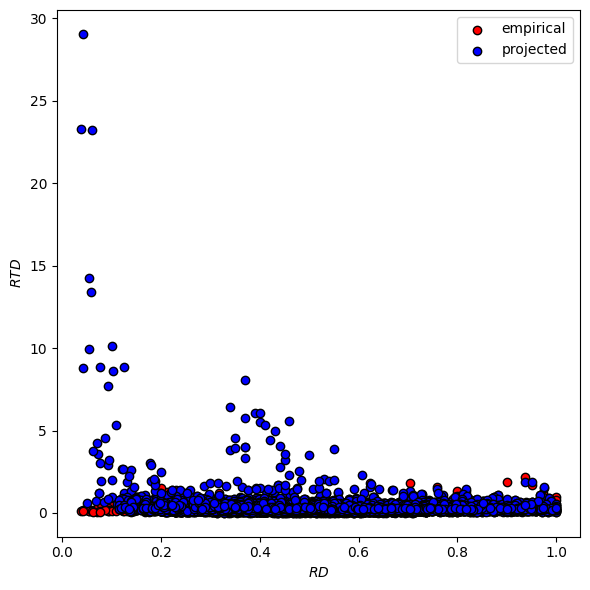

In [101]:
# before we fill the NaNs in RTD with calculated values, check how close our calculations are to actual values where RTD data is available

all_three_traits = subset.query(r"not F00709.isna()").loc[:, CHOSEN_ROOT_TRAITS]

fig, axes = plt.subplots()
fig.set_size_inches(6, 6)
axes.scatter(x=all_three_traits.F00679, y=all_three_traits.F00709, color="red", edgecolor="black", label="empirical")
axes.scatter(x=all_three_traits.F00679, y=back_calculate_rtd(all_three_traits.F00679.values, all_three_traits.F00727.values), color="blue", edgecolor="black", label="projected")
axes.set_xlabel(r"$RD$")
axes.set_ylabel(r"$RTD$")
axes.legend()
plt.tight_layout()
plt.show()

In [104]:
# that's concerningly low????
pearsonr(x=all_three_traits.F00709, y=back_calculate_rtd(all_three_traits.F00679.values, all_three_traits.F00727.values))

PearsonRResult(statistic=np.float64(0.1940890421715866), pvalue=np.float64(1.8262099893534333e-45))

In [142]:
# CHOOSING NOT TO BACK CALCULATE THE RTD VALUES
#------------------------------------------------

# fill the NaNs in the RTD column with manual calculations
# subset.loc[subset.F00709.isna(), "F00709"] = back_calculate_rtd(rd=subset.query(r"F00709.isna()").loc[:, "F00679"], srl=subset.query(r"F00709.isna()").loc[:, "F00727"])
# subset.isna().sum() # cool 

In [105]:
# abandon the plan to back propagate RTD values and drop the records that have missing RTD values
subset.dropna(subset="F00709", inplace=True)
subset.isna().mean()

F01286    0.000000
F01287    0.000000
F01289    0.000000
F01290    0.000000
F00679    0.000000
F00727    0.000000
F00709    0.000000
F00056    0.721349
F00645    0.589115
dtype: float64

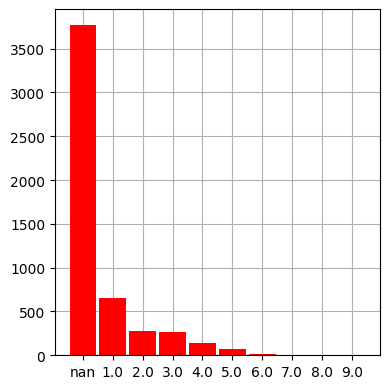

In [106]:
# examine the root orders within this RD <= 1.00 mm subset

freq = subset.F00056.value_counts(dropna=False)
fig, axes = plt.subplots()
fig.set_size_inches(4, 4)
axes.bar(x=freq.index.fillna(0), # without replacing with 0s, NaNs get ignored in x???
         height=freq.values, width=0.9, color="red")
axes.grid()
axes.set_axisbelow(True)
axes.set_xticks(ticks=np.linspace(start=0, stop=freq.size - 1, num=freq.size), labels=freq.index)
plt.tight_layout()
plt.show()

In [145]:
lookup.loc[subset.F01286.unique(), :]

KeyError: "['Austroblechnum', 'Cranfillia', 'Pectinopitys', 'Helesia', 'Tetrapilus', 'Heptapleurum', 'Veronia', 'Prasoxylon', 'Pseudodictamnus', 'Chrysojasminum', 'Hesperostipa', 'Rubroshorea', 'Wurfbainia', 'Andesanthus', 'Imbralyx', 'Alseodaphnopsis', 'Hymenopus', 'Leptobalanus', 'Eumachia'] not in index"

In [146]:
# we need to manually cross check these genera

# Austroblechnum
# Cranfillia
# Pectinopitys
# Helesia
# Tetrapilus
# Heptapleurum
# Veronia
# Prasoxylon
# Pseudodictamnus
# Chrysojasminum
# Hesperostipa
# Rubroshorea
# Wurfbainia
# Andesanthus
# Imbralyx
# Alseodaphnopsis
# Hymenopus
# Leptobalanus
# Eumachia

In [147]:
# for the genera that the lookup table has taxonomic data for, do the crosschecking
lookup_merged = pd.merge(left=subset.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].query(r"F01286.isin(@lookup.index)").drop_duplicates(),
                         left_on="F01286", right=lookup, right_index=True, how="left").reset_index(drop=True)
lookup_merged

,F01286,F01287,F01289,F01290,family,order,group
0,Larix,gmelinii,Pinaceae,Pinales,Pinaceae,Pinales,Gymnosperms
1,Fraxinus,mandshurica,Oleaceae,Lamiales,Oleaceae,Lamiales,Angiosperms
2,Populus,trichocarpa,Salicaceae,Malpighiales,Salicaceae,Malpighiales,Angiosperms
3,Populus,tremula,Salicaceae,Malpighiales,Salicaceae,Malpighiales,Angiosperms
4,Cinnamomum,micranthum,Lauraceae,Laurales,Lauraceae,Laurales,Angiosperms
...,...,...,...,...,...,...,...
1269,Sorocea,muriculata,Moraceae,Rosales,Moraceae,Rosales,Angiosperms
1270,Stachyarrhena,acuminata,Rubiaceae,Gentianales,Rubiaceae,Gentianales,Angiosperms
1271,Trymatococcus,amazonicus,Moraceae,Rosales,Moraceae,Rosales,Angiosperms
1272,Zygia,inaequalis,Fabaceae,Fabales,Fabaceae,Fabales,Angiosperms


In [148]:
# family level coflicts
lookup_merged.query(r"F01289!=family").drop_duplicates()

,F01286,F01287,F01289,F01290,family,order,group
32,Hedycarya,arborea,Minimiaceae,Laurales,Monimiaceae,Laurales,Angiosperms
112,Nyssa,sylvatica,Nyssaceae,Cornales,Cornaceae,Cornales,Angiosperms
367,Sambucus,williamsii,Viburnaceae,Dipsacales,Adoxaceae,Dipsacales,Angiosperms
504,Viburnum,dentatum,Viburnaceae,Dipsacales,Adoxaceae,Dipsacales,Angiosperms
531,Apodytes,dimidiata,Metteniusaceae,Metteniusales,Icacinaceae,Icacinales,Angiosperms
631,Viburnum,tinus,Viburnaceae,Dipsacales,Adoxaceae,Dipsacales,Angiosperms
700,Galearia,maingayi,Fabaceae,Fabales,Pandaceae,Malpighiales,Angiosperms
706,Nyssa,aquatica,Nyssaceae,Cornales,Cornaceae,Cornales,Angiosperms
875,Viburnum,stipitatum,Viburnaceae,Dipsacales,Adoxaceae,Dipsacales,Angiosperms
1004,Cephalotaxus,harringtonii,Cephalotaxaceae,Cupressales,Taxaceae,Pinales,Gymnosperms


In [149]:
# spelling mistakes in FRED are indicated with and asterisk*

# taxa that FRED has correctly
#---------------------------------

# Nyssa sylvatica - stick to FRED  https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:271953-1#higher-classification
# Sambucus williamsii - stick to FRED  https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:149409-1#higher-classification
# Viburnum dentatum - stick to FRED  https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:326264-2#higher-classification
# Apodytes dimidiata - stick to FRED  https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:434212-1#higher-classification
# Viburnum tinus - stick to FRED  https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:326271-2#higher-classification
# Nyssa aquatica - stick to FRED https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:302695-2#higher-classification
# Viburnum stipitatum - stick to FRED https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77175761-1#higher-classification

# taxa that need intervention
#---------------------------------

# Hedycarya arborea - *Monimiaceae, Laurales  https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:581882-1#higher-classification
# Galearia maingayi - Pandaceae, Malpighiales https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:349146-1#higher-classification
# Cephalotaxus harringtonii - Cephalotaxaceae, Pinales https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:261818-1#higher-classification
# Cryptocarya acutifolia - Lauraceae, Laurales https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:463781-1#higher-classification
# Barringtonia fusicarpa - Lecythidaceae, Ericales https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:104061-1#higher-classification
# Castanopsis indica - Fagaceae, Fagales https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:295397-1#higher-classification


In [150]:
# correct the above in the subset and remerge with the lookup table to incorporate the corrections

subset.loc[subset.query(r"F01286=='Hedycarya'").index, "F01289"] = "Monimiaceae"
subset.loc[subset.query(r"F01286=='Hedycarya'").index, "F01290"] = "Laurales"

subset.loc[subset.query(r"F01286=='Galearia'").index, "F01289"] = "Pandaceae"
subset.loc[subset.query(r"F01286=='Galearia'").index, "F01290"] = "Malpighiales"

subset.loc[subset.query(r"F01286=='Cephalotaxus'").index, "F01289"] = "Cephalotaxaceae"
subset.loc[subset.query(r"F01286=='Cephalotaxus'").index, "F01290"] = "Pinales"

subset.loc[subset.query(r"F01286=='Cryptocarya'").index, "F01289"] = "Lauraceae"
subset.loc[subset.query(r"F01286=='Cryptocarya'").index, "F01290"] = "Laurales"

subset.loc[subset.query(r"F01286=='Barringtonia'").index, "F01289"] = "Lecythidaceae"
subset.loc[subset.query(r"F01286=='Barringtonia'").index, "F01290"] = "Ericales"

subset.loc[subset.query(r"F01286=='Castanopsis'").index, "F01289"] = "Fagaceae"
subset.loc[subset.query(r"F01286=='Castanopsis'").index, "F01290"] = "Fagales"

In [151]:
# remerging after corrections, this is necessary since these corrections may have solved some of the order level conflicts
# so before reconciling the order level conflicts, do the remerger
lookup_merged = pd.merge(left=subset.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].query(r"F01286.isin(@lookup.index)").drop_duplicates(),
                         left_on="F01286", right=lookup, right_index=True, how="left").reset_index(drop=True)

In [152]:
# order level conflicts

# with pd.option_context("display.max_rows", 100, "display.max_columns", 10):
#     print(lookup_merged.query(r"F01290!=order").drop_duplicates())

lookup_merged.query(r"F01290!=order").drop_duplicates()

# even though our FRED subset has heaps of order level conflicts with the lookup table, U.PhyloMaker only expects the following columns:
# species, genus, family, species.relative, genus.relative
# don't waste time reconciling the orders :)

,F01286,F01287,F01289,F01290,family,order,group
15,Asplenium,bulbiferum,Aspleniaceae,Polypodiales,Aspleniaceae,Eupolypod II,Pteridophytes
18,Lomaria,discolor,Blechnaceae,Polypodiales,Blechnaceae,Eupolypod II,Pteridophytes
19,Parablechnum,novae-zelandiae,Blechnaceae,Polypodiales,Blechnaceae,Eupolypod II,Pteridophytes
20,Parablechnum,procerum,Blechnaceae,Polypodiales,Blechnaceae,Eupolypod II,Pteridophytes
28,Dacrydium,cupressinum,Podocarpaceae,Araucariales,Podocarpaceae,Pinales,Gymnosperms
...,...,...,...,...,...,...,...
1014,Dacrydium,balansae,Podocarpaceae,Araucariales,Podocarpaceae,Pinales,Gymnosperms
1015,Nageia,nagi,Podocarpaceae,Araucariales,Podocarpaceae,Pinales,Gymnosperms
1019,Chamaecyparis,pisifera,Cupressaceae,Cupressales,Cupressaceae,Pinales,Gymnosperms
1020,Ephedra,distachya,Ephedraceae,Ephedrales,Ephedraceae,Gnetales,Gymnosperms


In [153]:
# now, examine the genera that are missing in the lookup table
subset.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].query(r"not F01286.isin(@lookup.index)").drop_duplicates().sort_values(by=BINOMINAL_NAME)

,F01286,F01287,F01289,F01290
9264,Alseodaphnopsis,andersonii,Lauraceae,Laurales
8172,Andesanthus,lepidotus,Melastomataceae,Myrtales
483,Austroblechnum,lanceolatum,Blechnaceae,Polypodiales
5589,Chrysojasminum,fruticans,Oleaceae,Lamiales
485,Cranfillia,fluviatilis,Blechnaceae,Polypodiales
9493,Eumachia,astrellantha,Rubiaceae,Gentianales
9494,Eumachia,podocephala,Rubiaceae,Gentianales
952,Helesia,tetraptera,Styracaceae,Ericales
7803,Heptapleurum,heptaphyllum,Araliaceae,Apiales
1153,Heptapleurum,minutistellatum,Araliaceae,Apiales


In [154]:
# leave as is
#----------------------

# Alseodaphnopsis - https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77165678-1#higher-classification
# Andesanthus - https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77205900-1#higher-classification
# Chrysojasminum - https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77144221-1#higher-classification
# Eumachia - https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77154315-1#higher-classification
# Heptapleurum spp. - https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77196882-1#higher-classification
# Hesperostipa spp. - https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:969792-1#higher-classification
# Hymenopus spp. - https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77156951-1#higher-classification
# Imbralyx - https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77222791-1#higher-classification
# Leptobalanus spp. - https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:60472849-2#higher-classification
# Prasoxylon - https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77222487-1#higher-classification
# Pseudodictamnus - https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77191007-1#higher-classification
# Rubroshorea spp. - https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77298388-1#higher-classification
# Tetrapilus - https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:611203-1#higher-classification
# Wurfbainia - https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77178295-1#higher-classification

# corrections needed
#----------------------

# Austroblechnum lanceolatum - synonym of Blechnum chambersii - Aspleniaceae, Polypodiales https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:53460-3#higher-classification
# Helesia tetraptera - correct the spelling error in FRED - Halesia tetraptera - synonym of Halesia carolina - Styracaceae, Ericales https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:319532-2#higher-classification
# Cranfillia fluviatilis - synonym of Blechnum fluviatile - Aspleniaceae, Polypodiales https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:17058940-1#higher-classification
# Pectinopitys ferruginea - Podocarpaceae, Pinales https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:77203782-1#higher-classification
# Veronia fasciculata - misspelt - Vernonia fasciculata - https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:258347-1#higher-classification


In [155]:
subset.loc[subset.query(r"F01286=='Helesia' and F01287=='tetraptera'").index, "F01286"] = "Halesia"

subset.loc[subset.query(r"F01286=='Austroblechnum' and F01287=='lanceolatum'").index, "F01286"] = "Blechnum"
subset.loc[subset.query(r"F01286=='Austroblechnum' and F01287=='lanceolatum'").index, "F01287"] = "chambersii"
subset.loc[subset.query(r"F01286=='Blechnum'").index, "F01289"] = "Aspleniaceae"
subset.loc[subset.query(r"F01286=='Blechnum'").index, "F01290"] = "Polypodiales"

subset.loc[subset.query(r"F01286=='Cranfillia' and F01287=='fluviatilis'").index, "F01286"] = "Blechnum"
subset.loc[subset.query(r"F01286=='Cranfillia' and F01287=='fluviatilis'").index, "F01287"] = "fluviatile"
subset.loc[subset.query(r"F01286=='Blechnum'").index, "F01289"] = "Aspleniaceae"
subset.loc[subset.query(r"F01286=='Blechnum'").index, "F01290"] = "Polypodiales"

subset.loc[subset.query(r"F01286=='Pectinopitys'").index, "F01289"] = "Podocarpaceae"
subset.loc[subset.query(r"F01286=='Pectinopitys'").index, "F01290"] = "Pinales"

subset.loc[subset.query(r"F01286=='Veronia' and F01287=='fasciculata'").index, "F01286"] = "Vernonia"

In [156]:
# now, cross check if any genera are classified under multiple families
[g for g in subset.F01286.unique() if subset.query(r"F01286==@g").loc[:, "F01289"].unique().size > 1]

[]

In [157]:
# one species classified under multiple orders, WE DON'T NEED TO RECTIFY THIS.......
[g for g in subset.F01286.unique() if subset.query(r"F01286==@g").loc[:, "F01290"].unique().size > 1]

['Vitis']

In [158]:
subset.query(r"F01286=='Vitis'").loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].drop_duplicates()

,F01286,F01287,F01289,F01290
3440,Vitis,vulpina,Vitaceae,Alismatales
3443,Vitis,vulpina,Vitaceae,Vitales
5637,Vitis,vinifera,Vitaceae,Vitales
7832,Vitis,amurensis,Vitaceae,Vitales


In [159]:
# let's fix it, why not
# https://powo.science.kew.org/taxon/urn:lsid:ipni.org:names:30478388-2#higher-classification
subset.loc[subset.query(r"F01286=='Vitis'").index, "F01290"] = "Vitales"

In [160]:
lookup_merged = pd.merge(left=subset.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].query(r"F01286.isin(@lookup.index)").drop_duplicates(),
                         left_on="F01286", right=lookup, right_index=True, how="left").reset_index(drop=True)

In [161]:
lookup_merged.query(r"F01289!=family").drop_duplicates(subset=BINOMINAL_NAME)

,F01286,F01287,F01289,F01290,family,order,group
18,Blechnum,lanceolatum,Aspleniaceae,Polypodiales,Blechnaceae,Eupolypod II,Pteridophytes
20,Blechnum,fluviatilis,Aspleniaceae,Polypodiales,Blechnaceae,Eupolypod II,Pteridophytes
115,Nyssa,sylvatica,Nyssaceae,Cornales,Cornaceae,Cornales,Angiosperms
371,Sambucus,williamsii,Viburnaceae,Dipsacales,Adoxaceae,Dipsacales,Angiosperms
507,Viburnum,dentatum,Viburnaceae,Dipsacales,Adoxaceae,Dipsacales,Angiosperms
534,Apodytes,dimidiata,Metteniusaceae,Metteniusales,Icacinaceae,Icacinales,Angiosperms
634,Viburnum,tinus,Viburnaceae,Dipsacales,Adoxaceae,Dipsacales,Angiosperms
709,Nyssa,aquatica,Nyssaceae,Cornales,Cornaceae,Cornales,Angiosperms
878,Viburnum,stipitatum,Viburnaceae,Dipsacales,Adoxaceae,Dipsacales,Angiosperms
1007,Cephalotaxus,harringtonii,Cephalotaxaceae,Pinales,Taxaceae,Pinales,Gymnosperms


In [166]:
# taxa that we need to find mycorrhizal state data for
subset.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].drop_duplicates(subset=BINOMINAL_NAME).reset_index(drop=True)

,F01286,F01287,F01289,F01290
0,Larix,gmelinii,Pinaceae,Pinales
1,Fraxinus,mandshurica,Oleaceae,Lamiales
2,Populus,trichocarpa,Salicaceae,Malpighiales
3,Populus,tremula,Salicaceae,Malpighiales
4,Cinnamomum,micranthum,Lauraceae,Laurales
...,...,...,...,...
1296,Sorocea,muriculata,Moraceae,Rosales
1297,Stachyarrhena,acuminata,Rubiaceae,Gentianales
1298,Trymatococcus,amazonicus,Moraceae,Rosales
1299,Zygia,inaequalis,Fabaceae,Fabales


In [121]:
# average the trait values by species and log transform them
averaged_subset = subset.groupby(BINOMINAL_NAME, as_index=False).agg({"F00679": "mean", "F00727": "mean", "F00709": "mean"})#.apply({"F00679": np.log, "F00727": np.log, "F00709": np.log})
# log tranform
averaged_subset.F00679 = np.log(averaged_subset.F00679)
averaged_subset.F00727 = np.log(averaged_subset.F00727)
averaged_subset.F00709 = np.log(averaged_subset.F00709)

averaged_subset

,F01286,F01287,F00679,F00727,F00709
0,Abies,alba,-0.592397,3.466569,-1.409222
1,Abies,nephrolepis,-0.878915,3.297534,-1.274017
2,Acacia,auriculiformis,-0.711074,3.620422,-1.226446
3,Acacia,crassicarpa,-1.487530,4.684720,-1.021651
4,Acacia,mangium,-1.376146,4.597037,-1.237874
...,...,...,...,...,...
1296,Xanthophyllum,tenue,-0.830687,3.228004,-1.250890
1297,Zabelia,biflora,-0.636389,3.432278,-1.919393
1298,Zamia,lucayana,-1.116225,4.075373,-1.515606
1299,Zizia,aurea,-1.171183,4.605170,-2.040221


In [120]:
#-----------------------------------
# mycorrhizal states in FRED 4.0
#-----------------------------------

# consider only the species FRED 4.0 has mycorrhizal state info for
# doing this here so we can just load in the manually cleaned .csv into the state filling section
# we are using the whole FRED 4.0 dataset to look up mycorrhizal states, not just our subset!!!!

fred4_states = fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + ["F00645"]].dropna().drop_duplicates().sort_values(by=PLANT_TAXONOMY_ACCEPTED_COLUMNS).\
                reset_index(drop=True)

fred4_states.F00645.unique()

MYCORRHIZAL_STATE_REPLACEMENTS = { # mycorrhizal state encoding replacements
     "EM": "EcM",
     "AM + EM": "EcMAM",
     "AM + NM": "NMAM"
}

# drop the rows if F00645 is just "mycorrhizal" or any other useless stuff
fred4_states = fred4_states.query(r"not F00645.isin(['mycorrhizal', 'DS', 'EeM'])") 
fred4_states.loc[:, "F00645"] = fred4_states.F00645.replace(MYCORRHIZAL_STATE_REPLACEMENTS) # this contains many species we do not have continuous traits for.....

# cherry pick the records of species that we have continuous traits for!!!!
fred4_states = pd.merge(left=subset.loc[:, BINOMINAL_NAME].drop_duplicates(), left_on=BINOMINAL_NAME, right=fred4_states, right_on=BINOMINAL_NAME, how="inner").\
            drop_duplicates(subset=BINOMINAL_NAME + ["F00645"])

fred4_states.to_csv(r"../../data/chapter2/FRED/subsets/states_FRED4.csv", index=False) # this will need a little manual cleanup

In [123]:
# contains unique species
# RD, SRL & RTD values are species averaged
# all the continuous traits have been log transformed

continuous_traits = pd.merge(left=averaged_subset, left_on=BINOMINAL_NAME, right=subset.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].drop_duplicates(subset=BINOMINAL_NAME).reset_index(drop=True),
                            right_on=BINOMINAL_NAME, how="left").loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + CHOSEN_ROOT_TRAITS]
continuous_traits # good :)

,F01286,F01287,F01289,F01290,F00679,F00727,F00709
0,Abies,alba,Pinaceae,Pinales,-0.592397,3.466569,-1.409222
1,Abies,nephrolepis,Pinaceae,Pinales,-0.878915,3.297534,-1.274017
2,Acacia,auriculiformis,Fabaceae,Fabales,-0.711074,3.620422,-1.226446
3,Acacia,crassicarpa,Fabaceae,Fabales,-1.487530,4.684720,-1.021651
4,Acacia,mangium,Fabaceae,Fabales,-1.376146,4.597037,-1.237874
...,...,...,...,...,...,...,...
1296,Xanthophyllum,tenue,Polygalaceae,Fabales,-0.830687,3.228004,-1.250890
1297,Zabelia,biflora,Caprifoliaceae,Dipsacales,-0.636389,3.432278,-1.919393
1298,Zamia,lucayana,Zamiaceae,Cycadales,-1.116225,4.075373,-1.515606
1299,Zizia,aurea,Apiaceae,Apiales,-1.171183,4.605170,-2.040221


In [124]:
# this contains 1301 species averaged records => log transformed RD, SRL and RTD values and taxonomic information
continuous_traits.to_csv(r"../../data/chapter2/FRED/subsets/rd_srl_rtd_FRED4_1301sp_averaged_logged.csv", index=False)

### ___Mycorrhizal state filling___
-----------------------------

In [172]:
# unique taxa in FRED 4 RD <= 1.00 mm subset
taxa = pd.read_csv(r"../../data/chapter2/FRED/subsets/rd_srl_rtd_FRED4_1301sp_averaged_logged.csv").loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS]
taxa.loc[:, "binominal"] = taxa.loc[:, BINOMINAL_NAME].apply(' '.join, axis=1) # introduce a new column for binominal names

# mycorrhizal states in FRED 4.0 (from the respective data sources)
# this dataset is a hand cleaned version of the programatically cleaned and serialized .csv
fred4_states = pd.read_excel(r"../../data/chapter2/FRED/subsets/states.xlsx", sheet_name="FRED4")

# a trimmed .csv version of the FungalRoot species level dataset
fungalroot = pd.read_csv(r"../../data/chapter2/FungalRoot/fungalroot.csv", low_memory=False, header=0, skiprows=[1])
fungalroot.species = fungalroot.species.str.strip()

maherali = pd.read_csv(r"../../data/chapter2/Maherali.etal.AmNat.Data.csv", names=("binominal", "state"), skiprows=1)
maherali.binominal = maherali.binominal.str.replace('_', ' ').str.strip()

In [198]:
states_combined = fred4_states.loc[:, ("binominal", "F00645")].rename({"F00645": "state"}, axis=1)
states_combined.loc[:, "source"] = "FRED4"
states_combined

,binominal,state,source
0,Abies alba,EcM,FRED4
1,Abies nephrolepis,EcM,FRED4
2,Acacia auriculiformis,AM,FRED4
3,Acacia crassicarpa,EcMAM,FRED4
4,Acacia mangium,EcMAM,FRED4
...,...,...,...
768,Wurfbainia villosa,AM,FRED4
769,Xanthophyllum tenue,AM,FRED4
770,Zabelia biflora,AM,FRED4
771,Zamia lucayana,AM,FRED4


In [199]:
# species we need mycorrhizal states for
state_needed_species = taxa.query(r"not binominal.isin(@states_combined.binominal)").binominal
state_needed_species

12                 Acer laurinum
23          Achillea millefolium
28           Actinodaphne henryi
35           Afrocarpus falcatus
36          Agastache foeniculum
                  ...           
1289            Weinmannia ovata
1292         Withania frutescens
1294        Xanthisma spinulosum
1295    Xanthophyllum flavescens
1299                 Zizia aurea
Name: binominal, Length: 528, dtype: str

In [200]:
# let's check the Maherali 2016 dataset
maherali.query(r"binominal.isin(@state_needed_species)") # 121 additional species :)

,binominal,state
44,Achillea millefolium,AMNM
96,Agropyron cristatum,AM
100,Agrostis capillaris,AMNM
102,Agrostis scabra,AM
164,Ambrosia artemisiifolia,AM
...,...,...
2882,Verbascum thapsus,AM
2883,Verbena hastata,AM
2886,Vernonia fasciculata,AM
2902,Veronica persica,AM


In [202]:
states_combined = pd.concat([states_combined, maherali.query(r"binominal.isin(@state_needed_species)").assign(source="Maherali et al. (2016)")], axis=0)
states_combined

,binominal,state,source
0,Abies alba,EcM,FRED4
1,Abies nephrolepis,EcM,FRED4
2,Acacia auriculiformis,AM,FRED4
3,Acacia crassicarpa,EcMAM,FRED4
4,Acacia mangium,EcMAM,FRED4
...,...,...,...
2882,Verbascum thapsus,AM,Maherali et al. (2016)
2883,Verbena hastata,AM,Maherali et al. (2016)
2886,Vernonia fasciculata,AM,Maherali et al. (2016)
2902,Veronica persica,AM,Maherali et al. (2016)


In [207]:
state_needed_species = np.setdiff1d(taxa.binominal, states_combined.binominal)
state_needed_species.size

407

In [259]:
# we can also check the whole FRED 4.0 for these species instead of just looking at the subset that had intact continuous trait rows

whole_FRED4_states = fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS + ["F00645"]].dropna().drop_duplicates().reset_index(drop=True)
whole_FRED4_states.insert(loc=0, column="binominal", value=whole_FRED4_states.F01286.str.strip() + ' ' + whole_FRED4_states.F01287.str.strip())
whole_FRED4_states

,binominal,F01286,F01287,F01289,F01290,F00645
0,Dicranopteris linearis,Dicranopteris,linearis,Gleicheniaceae,Gleicheniales,AM
1,Cunninghamia lanceolata,Cunninghamia,lanceolata,Cupressaceae,Cupressales,AM
2,Magnolia baillonii,Magnolia,baillonii,Magnoliaceae,Magnoliales,AM
3,Acacia auriculiformis,Acacia,auriculiformis,Fabaceae,Fabales,AM
4,Polyspora axillaris,Polyspora,axillaris,Theaceae,Ericales,AM
...,...,...,...,...,...,...
3356,Sorocea muriculata,Sorocea,muriculata,Moraceae,Rosales,AM
3357,Stachyarrhena acuminata,Stachyarrhena,acuminata,Rubiaceae,Gentianales,AM
3358,Trymatococcus amazonicus,Trymatococcus,amazonicus,Moraceae,Rosales,AM
3359,Zygia inaequalis,Zygia,inaequalis,Fabaceae,Fabales,AM


In [264]:
# that's good :)
whole_FRED4_states.query(r"binominal.isin(@state_needed_species) and not F00645.isin(['DS', 'mycorrhizal'])").drop_duplicates(subset=["binominal", "F00645"])

,binominal,F01286,F01287,F01289,F01290,F00645
0,Dicranopteris linearis,Dicranopteris,linearis,Gleicheniaceae,Gleicheniales,AM
239,Magnolia macrophylla,Magnolia,macrophylla,Magnoliaceae,Magnoliales,AM
309,Endospermum chinense,Endospermum,chinense,Euphorbiaceae,Malpighiales,AM
404,Brachypodium phoenicoides,Brachypodium,phoenicoides,Poaceae,Poales,AM
411,Trifolium angustifolium,Trifolium,angustifolium,Fabaceae,Fabales,AM
572,Taraxacum campylodes,Taraxacum,campylodes,Asteraceae,Asterales,AM
630,Leymus chinensis,Leymus,chinensis,Poaceae,Poales,AM
631,Stipa krylovii,Stipa,krylovii,Poaceae,Poales,AM
635,Chamaerhodos erecta,Chamaerhodos,erecta,Rosaceae,Rosales,NM
639,Medicago ruthenica,Medicago,ruthenica,Fabaceae,Fabales,AM


In [269]:
whole_FRED4_states.query(r"binominal.isin(@state_needed_species) and not F00645.isin(['DS', 'mycorrhizal'])").drop_duplicates(subset=["binominal", "F00645"]).loc[:, ["binominal", "F00645"]].\
                        rename({"F00645": "state"}, axis=1).assign(source="FRED4")

,binominal,state,source
0,Dicranopteris linearis,AM,FRED4
239,Magnolia macrophylla,AM,FRED4
309,Endospermum chinense,AM,FRED4
404,Brachypodium phoenicoides,AM,FRED4
411,Trifolium angustifolium,AM,FRED4
572,Taraxacum campylodes,AM,FRED4
630,Leymus chinensis,AM,FRED4
631,Stipa krylovii,AM,FRED4
635,Chamaerhodos erecta,NM,FRED4
639,Medicago ruthenica,AM,FRED4


In [273]:
states_combined = pd.concat([states_combined, whole_FRED4_states.query(r"binominal.isin(@state_needed_species) and not F00645.isin(['DS', 'mycorrhizal'])").drop_duplicates(subset=["binominal", "F00645"]).loc[:, ["binominal", "F00645"]].\
                        rename({"F00645": "state"}, axis=1).assign(source="FRED4")], axis=0)
states_combined

,binominal,state,source
0,Abies alba,EcM,FRED4
1,Abies nephrolepis,EcM,FRED4
2,Acacia auriculiformis,AM,FRED4
3,Acacia crassicarpa,EcMAM,FRED4
4,Acacia mangium,EcMAM,FRED4
...,...,...,...
1857,Matteuccia struthiopteris,AM,FRED4
1896,Lactuca tatarica,AM,FRED4
2050,Pinus pinea,EM,FRED4
2128,Sibbaldianthe bifurca,AM,FRED4


In [275]:
state_needed_species = np.setdiff1d(taxa.binominal, states_combined.binominal)
state_needed_species.size

377

In [279]:
#-----------
# synonyms
#-----------

# let's look at synonyms - my be we could salvage a few more species
# look up https://diatoms.org/news/faq-what-are-homotypic-and-heterotypic-synonyms for homotypic synonyms vs heterotypic synonyms
# World Checklist of Vascular Plants (WCVP) dataset from => https://sftp.kew.org/pub/data-repositories/WCVP/

wcvp = pd.read_csv(r"../../data/chapter2/wcvp/wcvp_names.csv", low_memory=False, sep='|', true_values=['T'])

WCVP_COLUMNS = [
    "taxon_name", # full binominal name
    "plant_name_id", # World Checklist of Vascular Plants (WCVP) identifier
    "accepted_plant_name_id", # the ID of the accepted name of this taxon. Where the taxon_status is "Accepted", this will be identical to the plant_name_id value. May be empty if taxon status is unplaced, ilegitimate, or in some cases where the accepted name is not a vascular plant (e.g. a moss, alga or animal).
    "basionym_plant_name_id", # ID of the original name that taxon_name was derived from. If there is a parenthetical author it is a basionym. If there is a replaced synonym author it is a replaced synonym. If empty there have been no name changes. 
    "taxon_status", # indication of nomenclatural status and taxonomic opinion regarding the name
    "homotypic_synonym" # boolan indicating if the name is a homotypic synonym
]

In [282]:
synonym_pairs = wcvp.loc[:, WCVP_COLUMNS].query(r"taxon_status=='Synonym' and homotypic_synonym and (plant_name_id!=accepted_plant_name_id)").loc[:, ("taxon_name", "plant_name_id", "accepted_plant_name_id")]
synonym_pairs = synonym_pairs.astype({"plant_name_id": int, "accepted_plant_name_id": int}).reset_index(drop=True)
synonym_pairs.head()

,taxon_name,plant_name_id,accepted_plant_name_id
0,Caladenia glossodia,28587,520311
1,Caladenia gunnii,28592,38973
2,Clerodendrum acerbianum,42362,213992
3,Cochlidiosperma sibthorpioides,2730010,2462211
4,Veronica hederifolia subsp. sibthorpioides,2462927,2462211


In [283]:
wcvp_synonyms_lookup_table = pd.merge(left=synonym_pairs, left_on="accepted_plant_name_id", right=wcvp.loc[:, WCVP_COLUMNS], right_on="plant_name_id", how="left", suffixes=("_syn", '')).\
        loc[:, ("taxon_name", "taxon_name_syn")]
wcvp_synonyms_lookup_table.head()

,taxon_name,taxon_name_syn
0,Caladenia minorata,Caladenia glossodia
1,Chiloglottis gunnii,Caladenia gunnii
2,Volkameria acerbiana,Clerodendrum acerbianum
3,Veronica sibthorpioides,Cochlidiosperma sibthorpioides
4,Veronica sibthorpioides,Veronica hederifolia subsp. sibthorpioides


In [284]:
# let's see if the species we need state info have synonyms
wcvp_synonyms_lookup_table.query("taxon_name.isin(@state_needed_species)") # that's awesome!!!!!!!!!

,taxon_name,taxon_name_syn
1155,Viola adunca,Viola canina var. adunca
1318,Weinmannia fagaroides,Windmannia fagaroides
1708,Weinmannia ovata,Windmannia ovata
1729,Weinmannia elliptica,Windmannia elliptica
1778,Withania frutescens,Physalis frutescens
...,...,...
280952,Pappobolus microphyllus,Helianthus microphyllus
280966,Helianthus praecox,Helianthus debilis subsp. praecox
280967,Helianthus praecox,Helianthus cucumerifolius var. praecox
280969,Helianthus radula,Helianthus atrorubens subsp. radula


In [285]:
# the otherway around
wcvp_synonyms_lookup_table.query("taxon_name_syn.isin(@state_needed_species)") # not as many, but still something

,taxon_name,taxon_name_syn
75193,Camphora glandulifera,Cinnamomum glanduliferum
83514,Phyllanthus lanceolarius,Glochidion lanceolarium
101568,Meriania macrophylla subsp. franciscana,Meriania franciscana
109422,Andea infrafoveolata,Ocotea infrafoveolata
111211,Anacis palmata,Coreopsis palmata
121879,Paratrophis insignis,Morus insignis
162790,Phyllanthus eriocarpus,Glochidion eriocarpum
181980,Heterotheca villosa,Chrysopsis villosa
278815,Symphyotrichum lanceolatum,Aster lanceolatus


In [286]:
synonyms_state_needed_species = pd.concat([wcvp_synonyms_lookup_table.query("taxon_name_syn.isin(@state_needed_species)"), 
          wcvp_synonyms_lookup_table.query("taxon_name.isin(@state_needed_species)")], axis=0).reset_index(drop=True)
synonyms_state_needed_species

,taxon_name,taxon_name_syn
0,Camphora glandulifera,Cinnamomum glanduliferum
1,Phyllanthus lanceolarius,Glochidion lanceolarium
2,Meriania macrophylla subsp. franciscana,Meriania franciscana
3,Andea infrafoveolata,Ocotea infrafoveolata
4,Anacis palmata,Coreopsis palmata
...,...,...
435,Pappobolus microphyllus,Helianthus microphyllus
436,Helianthus praecox,Helianthus debilis subsp. praecox
437,Helianthus praecox,Helianthus cucumerifolius var. praecox
438,Helianthus radula,Helianthus atrorubens subsp. radula


In [312]:
# prune off the subsp. and var. names from the columns as FRED 4.0 and Maherali 2016 datasets only use simple binominal names

synonyms_state_needed_species_trimmed = synonyms_state_needed_species.copy()
synonyms_state_needed_species_trimmed.taxon_name = synonyms_state_needed_species_trimmed.taxon_name.str.split().apply(lambda _list: _list[0] + ' ' + _list[1])
synonyms_state_needed_species_trimmed.taxon_name_syn = synonyms_state_needed_species_trimmed.taxon_name_syn.str.split().apply(lambda _list: _list[0] + ' ' + _list[1])

synonyms_state_needed_species_trimmed.drop_duplicates(inplace=True)
synonyms_state_needed_species_trimmed

,taxon_name,taxon_name_syn
0,Camphora glandulifera,Cinnamomum glanduliferum
1,Phyllanthus lanceolarius,Glochidion lanceolarium
2,Meriania macrophylla,Meriania franciscana
3,Andea infrafoveolata,Ocotea infrafoveolata
4,Anacis palmata,Coreopsis palmata
...,...,...
435,Pappobolus microphyllus,Helianthus microphyllus
436,Helianthus praecox,Helianthus debilis
437,Helianthus praecox,Helianthus cucumerifolius
438,Helianthus radula,Helianthus atrorubens


In [313]:
# we could look these up again in FRED 4.0 and Maherali 2016 datasets???

maherali.query(r"binominal.isin(@synonyms_state_needed_species_trimmed.taxon_name)")

,binominal,state


In [314]:
maherali.query(r"binominal.isin(@synonyms_state_needed_species_trimmed.taxon_name_syn)") # :)

,binominal,state
198,Antennaria dioica,AM
209,Anthyllis cytisoides,AM
244,Armeria maritima,AMNM
247,Arnica montana,AM
602,Carex supina,NM
1202,Fraxinus americana,AM
1333,Helianthus annuus,AM
1646,Linum perenne,AMNM
2564,Shorea leprosula,EM
2772,Thymus vulgaris,AM


In [317]:
# look up these synonyms in FRED 4.0

whole_FRED4_states.query(r"binominal.isin(@synonyms_state_needed_species_trimmed.taxon_name)")

,binominal,F01286,F01287,F01289,F01290,F00645
2861,Sarcandra glabra,Sarcandra,glabra,Chloranthaceae,Chloranthales,mycorrhizal
2873,Sorbus discolor,Sorbus,discolor,Rosaceae,Rosales,mycorrhizal
2951,Lespedeza thunbergii,Lespedeza,thunbergii,Fabaceae,Fabales,mycorrhizal


In [318]:
whole_FRED4_states.query(r"binominal.isin(@synonyms_state_needed_species_trimmed.taxon_name_syn)")

,binominal,F01286,F01287,F01289,F01290,F00645
131,Antennaria dioica,Antennaria,dioica,Asteraceae,Asterales,AM
228,Fraxinus americana,Fraxinus,americana,Oleaceae,Lamiales,AM
290,Litsea baviensis,Litsea,baviensis,Lauraceae,Laurales,AM
316,Celtis sinensis,Celtis,sinensis,Cannabaceae,Rosales,AM
411,Trifolium angustifolium,Trifolium,angustifolium,Fabaceae,Fabales,AM
610,Carex supina,Carex,supina,Cyperaceae,Poales,AM + NM
699,Vitis vinifera,Vitis,vinifera,Vitaceae,Vitales,AM
1137,Carex supina,Carex,supina,Cyperaceae,Poales,NM
1796,Linum perenne,Linum,perenne,Linaceae,Malpighiales,AM
2660,Viola canina,Viola,canina,Violaceae,Malpighiales,AM


In [319]:
#------------------------------
# now, look through FungalRoot
#------------------------------

fungalroot.query(r"species.isin(@state_needed_species)").species.unique()

<StringArray>
[               'Erica arborea',          'Juniperus phoenicea',
       'Astragalus scaberrimus',               'Sextonia rubra',
           'Protium sagotianum',           'Combretum collinum',
           'Hakea ceratophylla',            'Hakea lissocarpha',
         'Carpinus caroliniana',               'Fraxinus nigra',
                  'Osyris alba',            'Thymelaea hirsuta',
                 'Poa cusickii',               'Quercus glauca',
           'Onoclea sensibilis',           'Chrysopsis villosa',
              'Rubia peregrina',       'Solidago missouriensis',
          'Antennaria neglecta', 'Symphyotrichum novae-angliae',
         'Eragrostis trichodes',    'Helianthus grosseserratus',
            'Helianthus mollis',       'Helianthus pauciflorus',
            'Solidago speciosa',          'Actinodaphne henryi',
    'Castanopsis calathiformis',             'Litsea panamanja',
            'Phoebe puwenensis',          'Machilus tenuipilis',
           

In [320]:
# FungalRoot has many subspecies names and variety names in addition to plain binominal names, hence avoiding the easier Series.isin()
# we need the names used in FungalRoot, not FRED 4.0, to fish out the state info from FungalRoot
matched_species = pd.Series([fsp for fsp in fungalroot.species for sp in state_needed_species if (sp in fsp)]).unique()
matched_species # well that's disappointing

<StringArray>
['Amelanchier alnifolia var. semi-integrifolia',
                                'Erica arborea',
                          'Juniperus phoenicea',
                       'Astragalus scaberrimus',
                               'Sextonia rubra',
                           'Protium sagotianum',
                           'Combretum collinum',
                           'Hakea ceratophylla',
                            'Hakea lissocarpha',
                         'Carpinus caroliniana',
                               'Fraxinus nigra',
                                  'Osyris alba',
                            'Thymelaea hirsuta',
                                 'Poa cusickii',
                               'Quercus glauca',
                           'Onoclea sensibilis',
                           'Chrysopsis villosa',
                              'Rubia peregrina',
                       'Solidago missouriensis',
                          'Antennaria neglecta',
      

In [ ]:
fungalroot.query(r"species.isin(@matched_species)").drop_duplicates(subset=["species", "mycorrhiza type"])